# langkah 1: persiapan data & EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, r2_score, silhouette_score
import shap

In [2]:
# Membuat Dataset Sintetis
np.random.seed(42)
n_samples = 500
df = pd.DataFrame({
'Suhu': np.random.normal(27, 5, n_samples),
'Polusi_PM25': np.random.normal(50, 20, n_samples),
'Volume_Trafik': np.random.randint(100, 1000, n_samples)
})

# Target Regresi: Konsumsi Energi (kWh)
df['Energi'] = 10 + (0.5 * df['Suhu']) + (0.02 * df['Volume_Trafik']) + np.random.normal(0, 1,
n_samples)

# Target Klasifikasi: Status Udara (1: Bahaya jika Polusi > 75, else 0)
df['Status_Udara'] = (df['Polusi_PM25'] > 75).astype(int)

# Langkah 2: Preprocessing (the pipeline)

In [4]:
# Scaling Fitur
features = ['Suhu', 'Polusi_PM25', 'Volume_Trafik']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# Splitting Data untuk Supervised Learning
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(

X_scaled, df['Energi'], df['Status_Udara'], test_size=0.2, random_state=42,
stratify=df['Status_Udara']
)

# Langkah 3: eksekusi tigas model (klaster, regesi, klasifikasi)

In [5]:
# 1. Klastering (Unsupervised) - Mencari Segmentasi Wilayah
kmeans = KMeans(n_clusters=3, random_state=42).fit(X_scaled)
df['Cluster'] = kmeans.labels_

# 2. Regresi (Supervised) - Prediksi Energi
reg_model = LinearRegression().fit(X_train, y_reg_train)
y_reg_pred = reg_model.predict(X_test)

# 3. Klasifikasi (Supervised) - Status Kualitas Udara
clf_model = MLPClassifier(hidden_layer_sizes=(5,5), max_iter=500, random_state=42).fit(X_train,
y_clf_train)
y_clf_pred = clf_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


# Langkah 4: audit model dengan XAI

  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_2075/3962024444.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test[:10], feature_names=features)


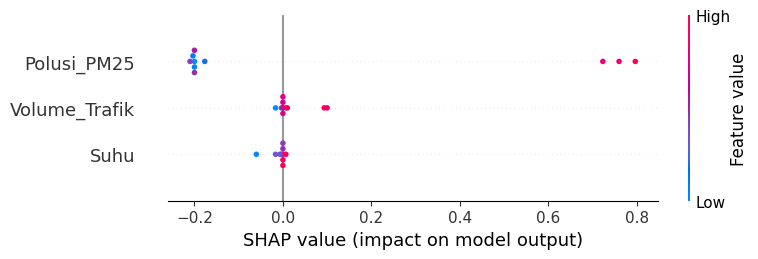

In [6]:
explainer = shap.KernelExplainer(clf_model.predict, X_train[:50])
shap_values = explainer.shap_values(X_test[:10])
shap.summary_plot(shap_values, X_test[:10], feature_names=features)